<a href="https://colab.research.google.com/github/RoseMaryBiju/Computer-Vision-Projects/blob/unit3/unit3_Road_Lane_%26_Traffic_Sign_Detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

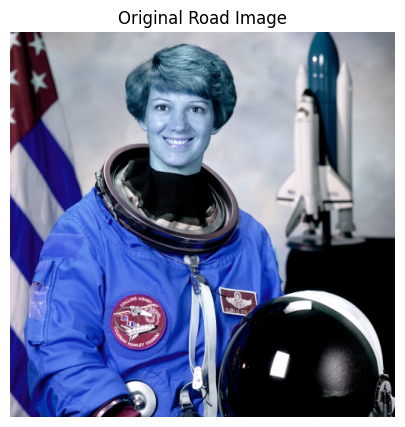

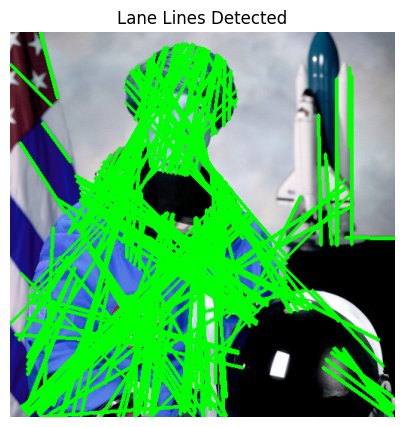

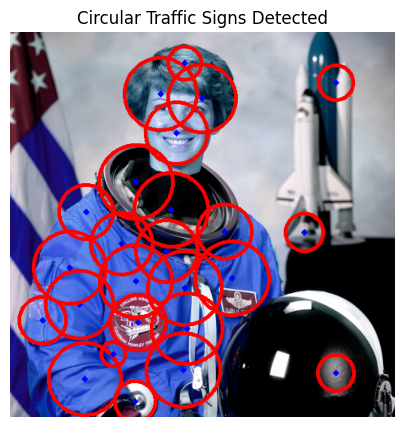

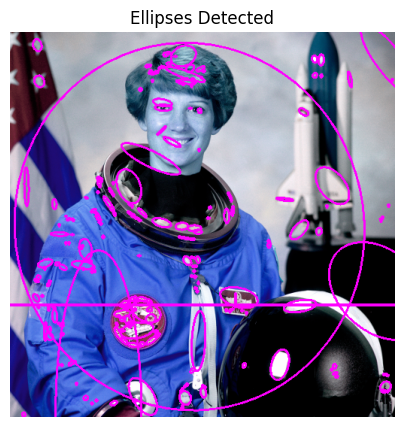

In [ ]:
# -------------------------------
# UNIT-3 APPLICATION: Lines, Circles and Ellipses Detection In Images
# -------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Load Sample  Image
# Using OpenCV sample image from GitHub
from skimage import data, color
image = data.astronaut()  # sample RGB image
gray = color.rgb2gray(image)
gray_uint8 = (gray * 255).astype(np.uint8)  # convert to uint8

plt.figure(figsize=(8,5))
plt.title("Original Road Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 2️⃣  Detection using Hough Line Transform
edges = cv2.Canny(gray_uint8, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=30)

lane_image = image.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(lane_image, (x1, y1), (x2, y2), (0,255,0), 3)

plt.figure(figsize=(8,5))
plt.title("Lane Lines Detected")
plt.imshow(cv2.cvtColor(lane_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 3️⃣ Circle Detection using Hough Circle Transform
blur = cv2.medianBlur(gray_uint8, 5)
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50,
                           param1=50, param2=30, minRadius=15, maxRadius=50)

sign_image = image.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(sign_image, (i[0], i[1]), i[2], (0,0,255), 3)
        cv2.circle(sign_image, (i[0], i[1]), 2, (255,0,0), 3)

plt.figure(figsize=(8,5))
plt.title("Circular Traffic Signs Detected")
plt.imshow(cv2.cvtColor(sign_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# 4️⃣  Ellipse Detection using contours
# Convert to binary
ret, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

ellipse_image = image.copy()
for cnt in contours:
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        cv2.ellipse(ellipse_image, ellipse, (255,0,255), 2)

plt.figure(figsize=(8,5))
plt.title("Ellipses Detected")
plt.imshow(cv2.cvtColor(ellipse_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()